<div style=" background-color: #439cc8;border-radius: 8px;font-size:2.5rem;" >
<h1 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">NOTEBOOK 1</h1>
<h2 style="margin: auto; padding: 20px 0; color:#fff; text-align: center">EDA données Autoscout24
</h2>
</div>

<div id="ch1" style="background-color: #439cc8;border-radius: 8px;font-size:2rem;" >
<h2  style="margin: auto; padding: 20px; color:#fff; ">1 - Import des modules et acquisition des données</h2>
</div>

<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    💡 Note : Sur Jupyter le sommaire est disponible dans le menu en sélectionnant View puis Table of Contents
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">1.1 - Adresses des données</h3>
</div>

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    Adresse des données : https://www.kaggle.com/datasets/wspirat/germany-used-cars-dataset-2023
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width:95%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">1.2 - Chargement</h3>
</div>

<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">1.2.1 - Import des librairies</h4>
</div>

In [1]:
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

from scipy.stats import chi2_contingency, anderson, kruskal, f_oneway

from collections import Counter

import re

pd.set_option("display.max_columns", 999)


<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">1.2.2 - Import des données</h4>
</div>

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    Indiquer le chemin où se trouve le fichier
</div>

In [2]:
raw = pd.read_csv(
    r"D:\ENI\CHAPITRE_09\used_cars_germany\data.csv", low_memory=False, sep=","
)
raw.head()


,Unnamed: 0,brand,model,color,registration_date,year,price_in_euro,power_kw,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,offer_description
0,0,alfa-romeo,Alfa Romeo GTV,red,10/1995,1995,1300,148,201,Manual,Petrol,"10,9 l/100 km",260 g/km,160500.0,2.0 V6 TB
1,1,alfa-romeo,Alfa Romeo 164,black,02/1995,1995,24900,191,260,Manual,Petrol,NaN,- (g/km),190000.0,"Q4 Allrad, 3.2L GTA"
2,2,alfa-romeo,Alfa Romeo Spider,black,02/1995,1995,5900,110,150,Unknown,Petrol,NaN,- (g/km),129000.0,ALFA ROME 916
3,3,alfa-romeo,Alfa Romeo Spider,black,07/1995,1995,4900,110,150,Manual,Petrol,"9,5 l/100 km",225 g/km,189500.0,2.0 16V Twin Spark L
4,4,alfa-romeo,Alfa Romeo 164,red,11/1996,1996,17950,132,179,Manual,Petrol,"7,2 l/100 km",- (g/km),96127.0,"3.0i Super V6, absoluter Topzustand !"


<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">1.2.3 - Petites corrections</h4>
</div>

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    La première variable est un index incrémentiel qui peut être immédiatement supprimé
</div>

In [3]:
raw = raw.drop(["Unnamed: 0"],axis=1)

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    Ensuite, nous renommerons la variable offer_description en version pour des raisons de commodités
</div>


In [4]:
raw.rename(columns={'offer_description': 'version'}, inplace=True)

<div style="background-color: #439cc8;border-radius: 8px;font-size:2rem;" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">2 - Nettoyage</h2>
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width:90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.1 - Contrôle général de la qualité des données</h3>
</div>

In [5]:
raw.shape

(251079, 14)

In [6]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 251079 entries, 0 to 251078
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   brand                     251079 non-null  object 
 1   model                     251079 non-null  object 
 2   color                     250913 non-null  object 
 3   registration_date         251075 non-null  object 
 4   year                      251079 non-null  object 
 5   price_in_euro             251079 non-null  object 
 6   power_kw                  250945 non-null  object 
 7   power_ps                  250950 non-null  object 
 8   transmission_type         251079 non-null  object 
 9   fuel_type                 251079 non-null  object 
 10  fuel_consumption_l_100km  224206 non-null  object 
 11  fuel_consumption_g_km     251079 non-null  object 
 12  mileage_in_km             250927 non-null  float64
 13  version                   251078 non-null  o

In [7]:
# Nombre total de cellules (lignes * colonnes)
total_cells = raw.shape[0] * raw.shape[1]

# Nombre de cellules non nulles
non_null_cells = raw.count().sum()

# Taux global moyen de remplissage (en pourcentage)
taux_remplissage = (non_null_cells / total_cells) * 100

print(f"Le taux global moyen de remplissage est de {taux_remplissage:.2f}%")


Le taux global moyen de remplissage est de 99.22%


<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    💡 Excellente qualité de remplissage (99.22%)
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.2 - Suppression des observations qui n'ont pas de prix numérique</h3>
</div>

In [8]:
raw["price"] = pd.to_numeric(raw["price_in_euro"], errors="coerce")
non_num_price = raw[raw["price"].isna() & raw["price_in_euro"].notna()]
non_num_price.shape


(199, 15)

<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 Nous disposons de 199 observations ne possédant pas un prix numérique. </p>
    <p>Ces observations vont être supprimées ainsi que l’ancienne variable price_in_euro</p>
</div>

In [9]:
raw = raw.drop(list(non_num_price.index),axis=0)
raw = raw.drop(["price_in_euro"],axis=1)

In [10]:
raw.shape

(250880, 14)

In [11]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250880 entries, 0 to 251078
Data columns (total 14 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   brand                     250880 non-null  object 
 1   model                     250880 non-null  object 
 2   color                     250714 non-null  object 
 3   registration_date         250880 non-null  object 
 4   year                      250880 non-null  object 
 5   power_kw                  250752 non-null  object 
 6   power_ps                  250752 non-null  object 
 7   transmission_type         250880 non-null  object 
 8   fuel_type                 250880 non-null  object 
 9   fuel_consumption_l_100km  224007 non-null  object 
 10  fuel_consumption_g_km     250880 non-null  object 
 11  mileage_in_km             250818 non-null  float64
 12  version                   250880 non-null  object 
 13  price                     250880 non-null  float6

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.3 - Exploration des variables</h3>
</div>

<div style="width: 50%; border-bottom: 1px solid #439cc8;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.3.1 - Les variables power</h4>
</div>

In [12]:
missing_pow1 = raw[raw["power_ps"].isna() & raw["power_kw"].notna()]
print(missing_pow1)


Empty DataFrame
Columns: [brand, model, color, registration_date, year, power_kw, power_ps, transmission_type, fuel_type, fuel_consumption_l_100km, fuel_consumption_g_km, mileage_in_km, version, price]
Index: []


In [13]:
display(raw[raw["power_ps"].isna()].head())


,brand,model,color,registration_date,year,power_kw,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,version,price
1396,alfa-romeo,Alfa Romeo Tonale,black,01/2023,2023,NaN,NaN,Automatic,Petrol,"5,9 l/100 km",134 g/km,15.0,SUPER 1.5 T 130PS 48-Hybrid 15KW,29970.0
1417,alfa-romeo,Alfa Romeo Tonale,black,01/2023,2023,NaN,NaN,Automatic,Hybrid,"5,9 l/100 km",134 g/km,5.0,SUPER 1.5 T 130PS 48-Hybrid 15KW,29970.0
1961,audi,Audi TT,silver,07/2001,2001,NaN,NaN,Manual,Other,NaN,- (g/km),154920.0,Roadster 1.8T quattro Mokassin-Naht,13900.0
19299,audi,Audi RS6,silver,06/2020,2020,NaN,NaN,Automatic,Petrol,"11,7 l/100 km",268 g/km,29874.0,Avant 4.0 TFSI quat/1064ps*/HGP/Keramik/VOLL,194999.0
20371,audi,Audi A6,silver,03/2021,2021,NaN,NaN,Automatic,Diesel,"4,9 l/100 km",128 g/km,74373.0,Avant design 40 TDI Aut quatt CAM AHK LED,34880.0


In [14]:
missing_pow2 = raw[raw["power_kw"].isna() & raw["power_ps"].notna()]
missing_pow2


,brand,model,color,registration_date,year,power_kw,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,version,price


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 power_ps et power_kw ont le même niveau de complétion</p>
    <p>Suppression de la variable power_kw qui est redondante</p>
</div>

In [15]:
raw = raw.drop(["power_kw"], axis=1)
raw["power_ps"] = pd.to_numeric(raw["power_ps"], errors="coerce")


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.3.2 - Les variables fuel_consumption</h4>
</div>

In [16]:
missing_cons1 = raw[
    raw["fuel_consumption_l_100km"].isna() & raw["fuel_consumption_g_km"].notna()
]
missing_cons1.head(20)


,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,version,price
1,alfa-romeo,Alfa Romeo 164,black,02/1995,1995,260.0,Manual,Petrol,NaN,- (g/km),190000.0,"Q4 Allrad, 3.2L GTA",24900.0
2,alfa-romeo,Alfa Romeo Spider,black,02/1995,1995,150.0,Unknown,Petrol,NaN,- (g/km),129000.0,ALFA ROME 916,5900.0
18,alfa-romeo,Alfa Romeo GTV,red,03/1997,1997,201.0,Manual,Petrol,NaN,- (g/km),168791.0,2.0 V6 TB - Leder - 2.Hand,9980.0
22,alfa-romeo,Alfa Romeo Spider,black,07/1997,1997,192.0,Manual,Petrol,NaN,- (g/km),194000.0,"3,0 V6 12V",10500.0
27,alfa-romeo,Alfa Romeo,black,09/1997,1997,207.0,Manual,Petrol,NaN,- (g/km),72260.0,RZ Zagato Spider | NR.172 | SAMMLER | IL MOSTRO,99900.0
41,alfa-romeo,Alfa Romeo Spider,red,05/1999,1999,106.0,Manual,Petrol,NaN,- (g/km),114000.0,Spider 1.8 Cabrio,3490.0
43,alfa-romeo,Alfa Romeo Spider,black,01/1999,1999,192.0,Manual,Petrol,NaN,- (g/km),193000.0,"3,0 V 6 12V",10900.0
57,alfa-romeo,Alfa Romeo 145,red,01/2000,2000,120.0,Manual,Petrol,NaN,- (g/km),128000.0,*Klima*El. Fenster*Alufelgen*Lederlenkr*,3480.0
76,alfa-romeo,Alfa Romeo 156,silver,07/2001,2001,150.0,Manual,Petrol,NaN,- (g/km),119079.0,2.0 TS 16V Limousine*Alufegen*,1350.0
85,alfa-romeo,Alfa Romeo 156,black,03/2002,2002,167.0,Manual,Diesel,NaN,- (g/km),148648.0,2.4 JTD,1490.0


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 26873 observations où fuel_consumption_g_km est complétée et fuel_consumption_l_100km ne l'est pas.</p>

</div>

In [17]:
missing_cons2 = raw[
    raw["fuel_consumption_g_km"].isna() & raw["fuel_consumption_l_100km"].notna()
]

missing_cons2

,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,version,price


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 Pas de cas où fuel_consumption_g_km est vide et fuel_consumption_l_100km ne l’est pas</p>

</div>

In [18]:
# Liste des colonnes à vérifier
cols_to_check = ["fuel_consumption_l_100km", "fuel_consumption_g_km"]

# Comptage des occurrences de "(Ort)" dans les colonnes spécifiées
count_ort = (
    raw[cols_to_check]
    .apply(lambda x: x.str.contains(r"Reichweite", na=False).sum())
    .sum()
)

print(count_ort)


4324


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 4324 observations contiennent la mention Reichweite qui est un mot allemand signifiant rayon d'action en français.</p>

</div>

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.3.3 - La variable fuel-type</h4>
</div>

In [19]:
raw.fuel_type.value_counts()

fuel_type
Petrol           143280
Diesel            86421
Hybrid            12607
Electric           5967
LPG                1255
CNG                 508
Diesel Hybrid       476
Other               178
Unknown              96
Hydrogen             82
Ethanol              10
Name: count, dtype: int64

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.4 - Corrections</h3>
</div>

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.4.1 - Attribution de 0 g/km lorsque la voiture est électrique</h4>
</div>

In [20]:
# Nous pouvons maintenant écrire 0 g/km lorsqu'il s'agit d'un véhicule électrique
raw.loc[raw["fuel_type"] == "Electric", "fuel_consumption_g_km"] = "0 g/km"


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.4.2 - fuel_consumption_g_km = manquant si le modèle est hybride et que fuel_consumption_g_km contient Reichweite</h4>
</div>

In [21]:
# Mise à jour de la colonne 'fuel_consumption_g_km' pour les véhicules hybrides contenant "Reichweite"
raw.loc[
    (raw["fuel_type"].str.contains("Hybrid", na=False))
    & (raw["fuel_consumption_g_km"].str.contains("Reichweite", na=False)),
    "fuel_consumption_g_km",
] = np.nan


In [22]:
raw.loc[raw["fuel_consumption_g_km"].str.contains('Reichweite', na=False)].head()

,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,version,price
17157,audi,Audi Q5,green,08/2019,2019,252.0,Automatic,Petrol,NaN,45 km Reichweite,53950.0,TFSI e 55 quattro 270(367) kW(PS) S tronic,44990.0
19190,audi,Audi Q5,black,06/2020,2020,367.0,Automatic,Petrol,NaN,45 km Reichweite,114680.0,S line 55TFSI e Navi LED Panorama B&O DAB GRA,39470.0
20014,audi,Audi A3,red,04/2021,2021,245.0,Automatic,Other,NaN,59 km Reichweite,20290.0,"45 Tfsi e S-line B&O, Vollausstattung,Anh.kupp...",38999.0
20104,audi,Audi A3,black,04/2021,2021,204.0,Automatic,Petrol,NaN,59 km Reichweite,31210.0,40TFSI e Stronic Klimaautomatik GRA,25970.0
20108,audi,Audi Q5,black,01/2021,2021,299.0,Automatic,Petrol,NaN,45 km Reichweite,43120.0,S-Line 50TFSI e qu. Stronic Navi LED GRA EPH,39970.0


In [23]:
nb_lig = raw["fuel_consumption_g_km"].str.contains('Reichweite', na=False).sum()
print(nb_lig)

49


<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 À l’issue de ces corrections, il reste 49 véhicules avec la mention Reichweite mais non répertoriés en hybride ou électrique.</p>
    <p>Nous les écarterons pour éviter des recherches trop chronophages. </p>

</div>

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.4.3 - Suppression des Reichweite restants</h4>
</div>

In [24]:
raw = raw.loc[~raw["fuel_consumption_g_km"].str.contains('Reichweite', na=False)]

In [25]:
raw["fuel_consumption_g_km"].value_counts()

fuel_consumption_g_km
- (g/km)        35809
0 g/km          11570
119 g/km         4813
114 g/km         3882
139 g/km         3389
                ...  
118.112 g/km        1
159,5 g/km          1
167,7 g/km          1
121,4 g/km          1
171,2 g/km          1
Name: count, Length: 1015, dtype: int64

<div style="
    background-color: #439cc8; 
    color: #FFF; 
    font-size: 16px; 
    font-style: italic; 
    border-left: 6px solid #439CC8; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 5px;">
    <p>💡 Combien de lignes n'ont pas g/km dans la colonne fuel_consumption_g_km ?</p>
</div>

In [26]:
lig_wo_gkm = raw.loc[
    (~raw["fuel_consumption_g_km"].str.contains("g/km", na=False))
    & (raw["fuel_consumption_g_km"].notna())
]

lig_wo_gkm.head(20)

,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,fuel_consumption_l_100km,fuel_consumption_g_km,mileage_in_km,version,price
43697,citroen,Citroen,grey,09/2008,2008,158.0,Manual,Diesel,NaN,-/-,344075.0,Jumper 160 HDI L1H1 KA *AHK*,4900.0
43711,citroen,Citroen,white,06/2008,2008,120.0,Manual,Diesel,NaN,-/-,145350.0,"Jumper 2,2 HDI L2H2 AHK,Standheizung,Klima,PDC",6285.0
43820,citroen,Citroen,white,09/2009,2009,101.0,Manual,Diesel,NaN,-/-,214456.0,Jumper Kasten Kühlwagen 30 L2H1 HDi 100,4990.0
43842,citroen,Citroen,grey,06/2010,2010,120.0,Manual,Diesel,NaN,-/-,220000.0,Jumper Pritsche Doka 33 L3/TÜV NEU*/7Sitze/EU4,7990.0
43870,citroen,Citroen,white,02/2010,2010,120.0,Manual,Diesel,NaN,-/-,174500.0,Jumper 2.2 Kasten 3 Sitzer L2 H2 TÜV NEU 1 Hand,7900.0
43889,citroen,Citroen,white,09/2010,2010,120.0,Manual,Diesel,NaN,-/-,109284.0,Jumper 2.2 HDi 30 L2H2 Klima Kamera,12990.0
43896,citroen,Citroen,grey,10/2011,2011,90.0,Manual,Diesel,NaN,-/-,172000.0,Berlingo L1*Klima*Händler*Export*TÜV 02/25,5988.0
43938,citroen,Citroen,white,08/2011,2011,120.0,Manual,Diesel,NaN,-/-,98000.0,jumper Dreiseitenkipper AHK,11900.0
43979,citroen,Citroen,grey,04/2012,2012,128.0,Manual,Diesel,NaN,-/-,230000.0,Jumpy HDi 125 FAP L2 Multispace Lang 9 Sitzer,7300.0
44014,citroen,Citroen,white,03/2012,2012,90.0,Manual,Diesel,NaN,-/-,265000.0,Berlingo Kasten Niveau B L1Wagen Nr.:038,5590.0


In [27]:
lig_wo_gkm["fuel_consumption_g_km"].value_counts()

fuel_consumption_g_km
-/-            882
44 km (Ort)      1
Name: count, dtype: int64

<div style="
    background-color: #439cc8; 
    color: #FFF; 
    font-size: 16px; 
    font-style: italic; 
    border-left: 6px solid #439CC8; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 5px;">
    💡 Les informations communiquées sous la forme XXX km (Ort) correspondent à la distance parcourue en ville pour une voiture électrique ou hybride.
</div>


In [28]:
# Liste des colonnes à vérifier
cols_to_check = ["fuel_consumption_l_100km", "fuel_consumption_g_km"]

# Comptage des occurrences de "(Ort)" dans les colonnes spécifiées
count_ort = (
    raw[cols_to_check].apply(lambda x: x.str.contains(r"\(Ort\)", na=False).sum()).sum()
)

print(count_ort)


483


<div style="
    background-color: #439cc8; 
    color: #FFF; 
    font-size: 16px; 
    font-style: italic; 
    border-left: 6px solid #439CC8; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 5px;">
    💡 Effectif trop faible pour créer une variable
</div>

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    Code pour nettoyer de manière contrôlée les variables numériques ayant des unités
</div>

In [29]:
def clean_variable(df, col_name, new_col_name, replacements, suffix="g/km"):
    # Créer une regex à partir des remplacements
    replacement_regex = "|".join(map(re.escape, replacements))

    # Nettoyage de la colonne
    df[col_name] = (
        df[col_name]
        .str.replace(replacement_regex, "", regex=True)
        .str.replace(",", ".")  # Virgules remplacées par des points
        .where(df[col_name].str.endswith(suffix), "")
        .replace("", np.nan)  # Chaînes vides remplacées par NaN
        .astype(float)  # Conversion en float
    )

    # Conversion en numérique avec gestion des erreurs
    df[new_col_name] = pd.to_numeric(df[col_name], errors="coerce")

    # Suppression de l'ancienne colonne
    df = df.drop(col_name, axis=1)

    return df


In [30]:
replacements = ["- (g/km)", "-/-", "9.999.999", " g/km"]
raw = clean_variable(
    raw,
    "fuel_consumption_g_km",
    "fuel_consumption_g_km_num",
    replacements,
    suffix="g/km",
)


In [31]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250831 entries, 0 to 251078
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   brand                      250831 non-null  object 
 1   model                      250831 non-null  object 
 2   color                      250665 non-null  object 
 3   registration_date          250831 non-null  object 
 4   year                       250831 non-null  object 
 5   power_ps                   250703 non-null  float64
 6   transmission_type          250831 non-null  object 
 7   fuel_type                  250831 non-null  object 
 8   fuel_consumption_l_100km   224000 non-null  object 
 9   mileage_in_km              250769 non-null  float64
 10  version                    250831 non-null  object 
 11  price                      250831 non-null  float64
 12  fuel_consumption_g_km_num  212872 non-null  float64
dtypes: float64(4), object(9)
memory us

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    Un véhicule électrique ne consomme pas de carburant
</div>

In [32]:
raw.loc[raw["fuel_type"] == "Electric", "fuel_consumption_l_100km"] = "0 l/100 km"


In [33]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250831 entries, 0 to 251078
Data columns (total 13 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   brand                      250831 non-null  object 
 1   model                      250831 non-null  object 
 2   color                      250665 non-null  object 
 3   registration_date          250831 non-null  object 
 4   year                       250831 non-null  object 
 5   power_ps                   250703 non-null  float64
 6   transmission_type          250831 non-null  object 
 7   fuel_type                  250831 non-null  object 
 8   fuel_consumption_l_100km   229496 non-null  object 
 9   mileage_in_km              250769 non-null  float64
 10  version                    250831 non-null  object 
 11  price                      250831 non-null  float64
 12  fuel_consumption_g_km_num  212872 non-null  float64
dtypes: float64(4), object(9)
memory us

In [34]:
raw.fuel_consumption_l_100km.value_counts()

fuel_consumption_l_100km
4,9 l/100 km     8158
5,1 l/100 km     7655
5,5 l/100 km     7614
5,9 l/100 km     7516
5,3 l/100 km     7435
                 ... 
9 kg/100 km         1
49 km (Ort)         1
22,6 l/100 km       1
92 km (Ort)         1
93 km (Ort)         1
Name: count, Length: 359, dtype: int64

In [35]:
replacements = ["- (l/100 km)", "-/-", " l/100 km"]

raw = clean_variable(
    raw,
    "fuel_consumption_l_100km",
    "fuel_consumption_l_100km_num",
    replacements,
    suffix="l/100 km",
)


In [36]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250831 entries, 0 to 251078
Data columns (total 13 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   brand                         250831 non-null  object 
 1   model                         250831 non-null  object 
 2   color                         250665 non-null  object 
 3   registration_date             250831 non-null  object 
 4   year                          250831 non-null  object 
 5   power_ps                      250703 non-null  float64
 6   transmission_type             250831 non-null  object 
 7   fuel_type                     250831 non-null  object 
 8   mileage_in_km                 250769 non-null  float64
 9   version                       250831 non-null  object 
 10  price                         250831 non-null  float64
 11  fuel_consumption_g_km_num     212872 non-null  float64
 12  fuel_consumption_l_100km_num  227830 non-null  fl

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.5 - Imputations</h3>
</div>

In [37]:
# Fonction pour trouver la valeur unique ou majoritaire
def get_majority_or_unique(series):
    non_null_values = series.dropna()
    if len(non_null_values) == 0:
        return pd.Series(dtype="float64")
    counter = Counter(non_null_values)
    if len(counter) == 1:
        # Si une seule valeur unique existe
        return non_null_values.iloc[0]
    else:
        # Sinon, retourne la valeur majoritaire (la plus fréquente)
        return counter.most_common(1)[0][0]


# Liste des colonnes à traiter
columns_to_fill = ["fuel_consumption_g_km_num", "fuel_consumption_l_100km_num"]

# Pour chaque caractéristique à remplir
for col in columns_to_fill:
    # Créer une colonne temporaire pour stocker les valeurs calculées (unique ou majoritaire)
    raw["temp_" + col] = raw.groupby(
        ["brand", "model", "version", "fuel_type", "year"]
    )[col].transform(lambda x: get_majority_or_unique(x))

    # Remplir les valeurs manquantes dans la colonne d'origine avec la colonne temporaire
    raw[col].fillna(raw["temp_" + col])

    # Supprimer la colonne temporaire
    raw.drop(columns=["temp_" + col], inplace=True)


# Afficher le dataframe pour vérifier
# print(df.head())


In [38]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250831 entries, 0 to 251078
Data columns (total 13 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   brand                         250831 non-null  object 
 1   model                         250831 non-null  object 
 2   color                         250665 non-null  object 
 3   registration_date             250831 non-null  object 
 4   year                          250831 non-null  object 
 5   power_ps                      250703 non-null  float64
 6   transmission_type             250831 non-null  object 
 7   fuel_type                     250831 non-null  object 
 8   mileage_in_km                 250769 non-null  float64
 9   version                       250831 non-null  object 
 10  price                         250831 non-null  float64
 11  fuel_consumption_g_km_num     212872 non-null  float64
 12  fuel_consumption_l_100km_num  227830 non-null  fl

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">2.6 - Finalisation</h3>
</div>

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.6.1 - Passage de year en numérique</h4>
</div>

In [39]:
raw['year'] = pd.to_numeric(raw['year'], errors='coerce')

In [40]:
raw.info()

<class 'pandas.core.frame.DataFrame'>
Index: 250831 entries, 0 to 251078
Data columns (total 13 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   brand                         250831 non-null  object 
 1   model                         250831 non-null  object 
 2   color                         250665 non-null  object 
 3   registration_date             250831 non-null  object 
 4   year                          250831 non-null  int64  
 5   power_ps                      250703 non-null  float64
 6   transmission_type             250831 non-null  object 
 7   fuel_type                     250831 non-null  object 
 8   mileage_in_km                 250769 non-null  float64
 9   version                       250831 non-null  object 
 10  price                         250831 non-null  float64
 11  fuel_consumption_g_km_num     212872 non-null  float64
 12  fuel_consumption_l_100km_num  227830 non-null  fl

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.6.2 - Point sur les types de variables</h4>
<p>year, price_in_euro, power_kw, power_ps, fuel_consumption_l_100km et fuel_consumption_g_km sont en object</p>
</div>

In [41]:
def isolate_non_numeric_values(df, colonne):
    # Tentative de conversion de la colonne en numérique
    df["temp_num"] = pd.to_numeric(df[colonne], errors="coerce")

    # Isolation des valeurs non numériques
    valeurs_non_numeriques = df[df["temp_num"].isna() & df[colonne].notna()]

    # Suppression de la colonne temporaire
    df.drop(columns=["temp_num"], inplace=True)

    return valeurs_non_numeriques[[colonne]]


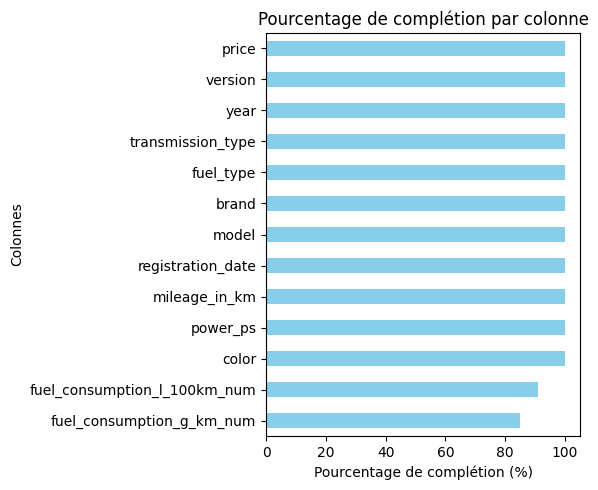

In [42]:
def plot_completion_percentage(df):
    # Calculer le pourcentage de complétion pour chaque colonne
    completion_percentage = df.notnull().mean() * 100

    # Créer un graphique
    plt.figure(figsize=(6, 5))
    completion_percentage.sort_values().plot(kind="barh", color="skyblue")

    # Ajouter des labels et un titre
    plt.xlabel("Pourcentage de complétion (%)")
    plt.ylabel("Colonnes")
    plt.title("Pourcentage de complétion par colonne")

    # Afficher le graphique
    plt.tight_layout()
    plt.show()


plot_completion_percentage(raw)


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">2.6.3 - Récupération du mois</h4>
</div>

In [43]:
raw["registration_date"] = pd.to_datetime(
    raw["registration_date"], format="%m/%Y", errors="coerce"
)

raw["month"] = raw["registration_date"].dt.month


In [44]:
df = raw.dropna().copy()

In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205645 entries, 0 to 251078
Data columns (total 14 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   brand                         205645 non-null  object        
 1   model                         205645 non-null  object        
 2   color                         205645 non-null  object        
 3   registration_date             205645 non-null  datetime64[ns]
 4   year                          205645 non-null  int64         
 5   power_ps                      205645 non-null  float64       
 6   transmission_type             205645 non-null  object        
 7   fuel_type                     205645 non-null  object        
 8   mileage_in_km                 205645 non-null  float64       
 9   version                       205645 non-null  object        
 10  price                         205645 non-null  float64       
 11  fuel_consumption_g

<div style="background-color: #439cc8;border-radius: 8px;font-size:2rem;width: 90%; " >
<h2 style="margin: auto; padding: 20px; color:#fff; ">3 - Exploration - Analyse</h2>
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">3.1 - Univarié</h3>
</div>

In [46]:
import plotly.io as pio

pio.renderers.default = (
    "plotly_mimetype"  # Option pour que cela s'affiche correctement sous Jupyter
)

# Pour Visual Studio Code, il faut écrire plotly_mimetype à la place de iframe


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.1.1 - Boxplot des prix</h4>
</div>

In [47]:
# Créer le boxplot horizontal avec échelle logarithmique
fig = px.box(
    df, x="price", title="Boxplot des prix (échelle logarithmique)", log_x=True
)

# Afficher le graphique
fig.show()


Les prix vont de 149 à 5 890 500 euros. Nous briderons notre échantillon à 1.5*IQR+Q3 soit 56222 euros max

In [48]:
df=df[df['price']<=56222].copy()


In [49]:
df.query("price==149")

,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,mileage_in_km,version,price,fuel_consumption_g_km_num,fuel_consumption_l_100km_num,month
168576,renault,Renault Espace,grey,2004-01-01,2004,120.0,Manual,Diesel,237500.0,"Expression IV Motorschaden, Teile ausgebaut",149.0,187.0,7.0,1


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.1.2 - Boxplot des années</h4>
</div>

In [50]:
fig = px.box(df, x="year", title="Boxplot des year", log_x=False)

# Afficher le graphique
fig.show()


In [51]:
df.shape

(192496, 14)

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">3.2 - Bivarié</h3>
</div>

<div style="
    color: #439CC8; 
    font-size: 16px; 
    font-style: italic; 
    text-align: left; 
    padding-left: 15px; 
    margin-bottom: 5px;">
    Code pour visualiser et analyser les liens bivariés
</div>

In [52]:
def analyze_data(df, num_var, cat_var):
    # Afficher le box plot
    plt.figure(figsize=(12, 4))
    sns.boxplot(y=cat_var, x=num_var, data=df, orient="h")
    plt.xscale("log")  # Appliquer une échelle logarithmique sur l'axe des ordonnées
    plt.title(f"Box Plot de {num_var} par {cat_var} avec échelle logarithmique\n")
    plt.show()

    # Test d'Anderson-Darling pour déterminer la normalité
    result = anderson(df[num_var])
    print("--- Résultats du test d'Anderson-Darling ---")
    print("Statistique d'Anderson-Darling:", result.statistic)
    print("Valeurs critiques:", result.critical_values)
    print("Niveaux de signification:", result.significance_level)

    # Test à effectuer en fonction de Anderson-Darling
    if result.statistic > result.critical_values[2]:  # 5% niveau de signification
        print(
            "Les données ne suivent pas une distribution normale. Effectuer le test de Kruskal-Wallis."
        )

        # Regrouper les données par la variable catégorielle
        groups = [group[num_var].values for name, group in df.groupby(cat_var)]

        # Test de Kruskal-Wallis
        stat, p_value = kruskal(*groups)

        # Résultats du test de Kruskal-Wallis
        print("--- Résultats du test de Kruskal-Wallis ---")
        print("Statistique de Kruskal-Wallis:", stat)
        print("P-value:", p_value)
    else:
        print("Les données suivent une distribution normale. Effectuer le test ANOVA.")

        # Regroupement des données par la variable catégorielle
        groups = [group[num_var].values for name, group in df.groupby(cat_var)]

        # Test ANOVA
        f_stat, p_value = f_oneway(*groups)

        # Affichage des résultats du test ANOVA
        print("--- Résultats du test ANOVA ---")
        print("Statistique F:", f_stat)
        print("P-value:", p_value)


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.2.1 - Boxplots des prix selon les années</h4>
</div>

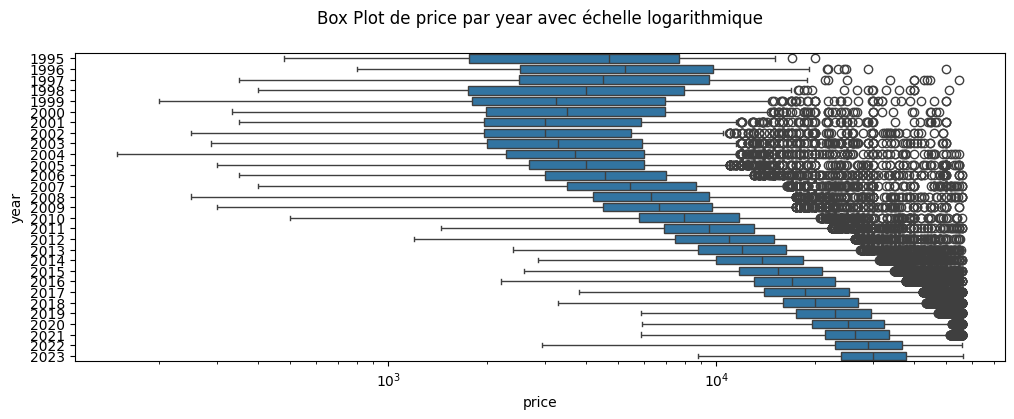

--- Résultats du test d'Anderson-Darling ---
Statistique d'Anderson-Darling: 1484.5629710554786
Valeurs critiques: [0.576 0.656 0.787 0.918 1.092]
Niveaux de signification: [15.  10.   5.   2.5  1. ]
Les données ne suivent pas une distribution normale. Effectuer le test de Kruskal-Wallis.
--- Résultats du test de Kruskal-Wallis ---
Statistique de Kruskal-Wallis: 99892.27283463858
P-value: 0.0


In [53]:
analyze_data(df, 'price', 'year')

<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    💡 Suppression des années antérieures à 2005 où la variabilité a tendance à augmenter 
</div>

In [54]:
df=df[df['year']>=2005].copy()

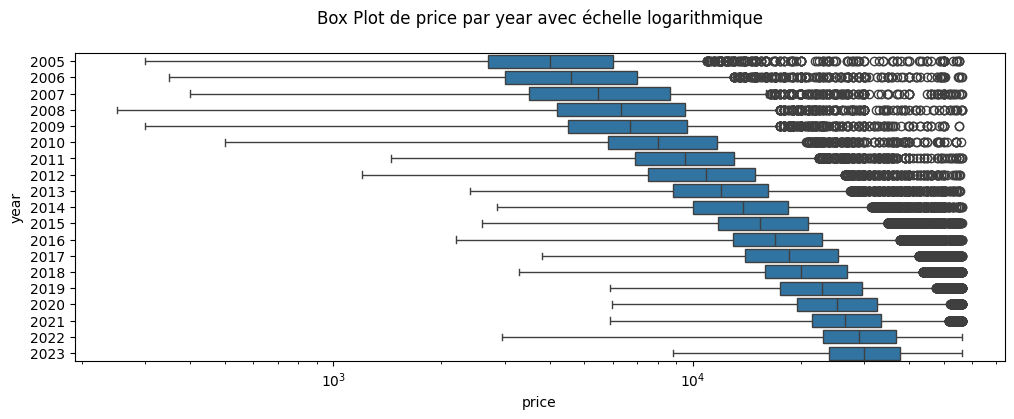

--- Résultats du test d'Anderson-Darling ---
Statistique d'Anderson-Darling: 1579.537322042248
Valeurs critiques: [0.576 0.656 0.787 0.918 1.092]
Niveaux de signification: [15.  10.   5.   2.5  1. ]
Les données ne suivent pas une distribution normale. Effectuer le test de Kruskal-Wallis.
--- Résultats du test de Kruskal-Wallis ---
Statistique de Kruskal-Wallis: 90844.24155163216
P-value: 0.0


In [55]:
analyze_data(df, 'price', 'year')

In [56]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 186088 entries, 135 to 251078
Data columns (total 14 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   brand                         186088 non-null  object        
 1   model                         186088 non-null  object        
 2   color                         186088 non-null  object        
 3   registration_date             186088 non-null  datetime64[ns]
 4   year                          186088 non-null  int64         
 5   power_ps                      186088 non-null  float64       
 6   transmission_type             186088 non-null  object        
 7   fuel_type                     186088 non-null  object        
 8   mileage_in_km                 186088 non-null  float64       
 9   version                       186088 non-null  object        
 10  price                         186088 non-null  float64       
 11  fuel_consumption

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.2.2 - Boxplots des prix selon le type de motorisation</h4>
</div>

In [57]:
df.fuel_type.value_counts()

fuel_type
Petrol           106168
Diesel            64846
Hybrid             9031
Electric           4913
LPG                 711
Diesel Hybrid       303
Other                66
CNG                  25
Unknown              22
Ethanol               3
Name: count, dtype: int64

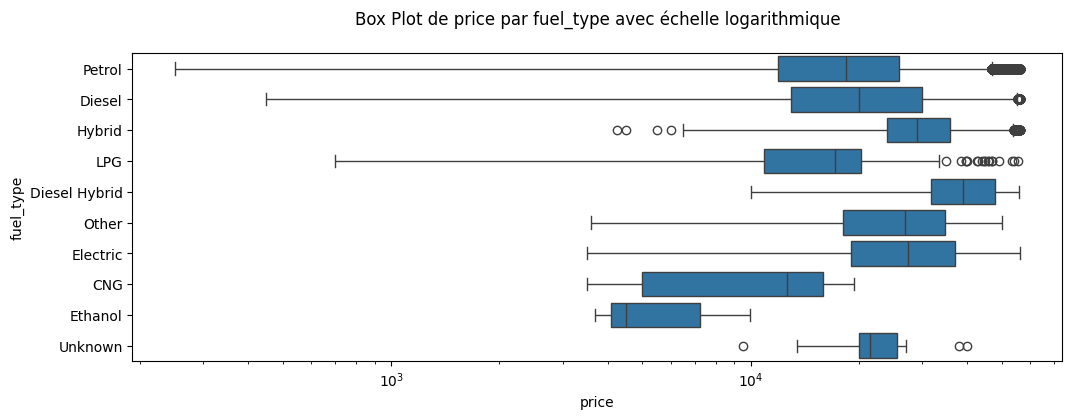

--- Résultats du test d'Anderson-Darling ---
Statistique d'Anderson-Darling: 1579.537322042248
Valeurs critiques: [0.576 0.656 0.787 0.918 1.092]
Niveaux de signification: [15.  10.   5.   2.5  1. ]
Les données ne suivent pas une distribution normale. Effectuer le test de Kruskal-Wallis.
--- Résultats du test de Kruskal-Wallis ---
Statistique de Kruskal-Wallis: 10871.546176339005
P-value: 0.0


In [58]:
analyze_data(df, 'price', 'fuel_type')

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 Le type de motorisation joue sur le prix</p>
    <p>Suppression des mentions anecdotiques inférieures à 100 </p>

</div>

In [59]:
# Calcul des effectifs de chaque groupe
fuel_counts = df["fuel_type"].value_counts()

# Sélection uniquement des types de carburant ayant au moins 100 occurrences
valid_fuel_types = fuel_counts[fuel_counts >= 100].index

# Filtrage du DataFrame
df = df[df["fuel_type"].isin(valid_fuel_types)]


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.2.3 - Boxplots des prix selon la couleur</h4>
</div>

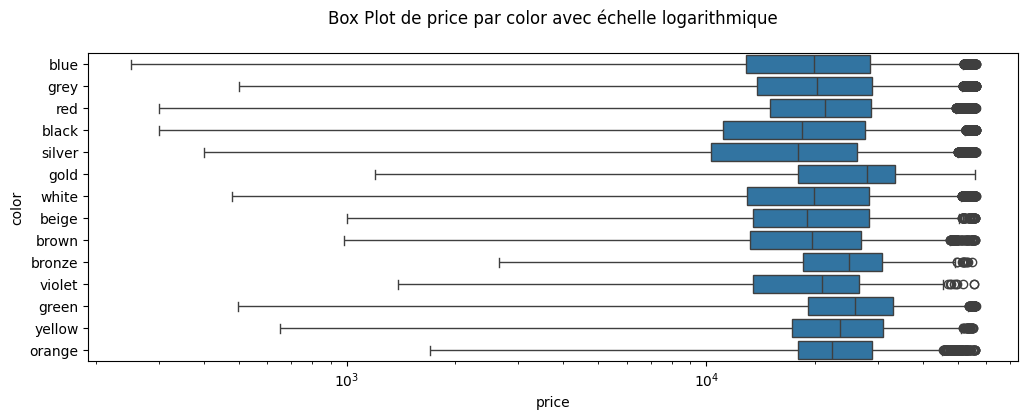

--- Résultats du test d'Anderson-Darling ---
Statistique d'Anderson-Darling: 1579.161208028032
Valeurs critiques: [0.576 0.656 0.787 0.918 1.092]
Niveaux de signification: [15.  10.   5.   2.5  1. ]
Les données ne suivent pas une distribution normale. Effectuer le test de Kruskal-Wallis.
--- Résultats du test de Kruskal-Wallis ---
Statistique de Kruskal-Wallis: 2769.0246635752446
P-value: 0.0


In [60]:
analyze_data(df, 'price', 'color')

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 La couleur joue sur le prix (P-value: 0.0)</p>
</div>

In [61]:
df.color.value_counts()

color
black     42165
grey      35241
white     31268
silver    24230
blue      23292
red       16952
brown      3460
orange     2792
green      2266
beige      1853
yellow     1312
gold        427
bronze      415
violet      299
Name: count, dtype: int64

In [62]:
df.head()

,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,mileage_in_km,version,price,fuel_consumption_g_km_num,fuel_consumption_l_100km_num,month
135,alfa-romeo,Alfa Romeo 147,blue,2005-10-01,2005,185.0,Manual,Petrol,126000.0,Brera,10599.0,287.0,12.1,10
136,alfa-romeo,Alfa Romeo Spider,blue,2005-06-01,2005,166.0,Manual,Petrol,203997.0,2.0 JTS Edizione 2005,5900.0,220.0,9.2,6
137,alfa-romeo,Alfa Romeo GT,grey,2005-06-01,2005,241.0,Manual,Petrol,143800.0,"3.2 V6 24V Distinctive Alfa-Scheckheft,1.Hand",17980.0,295.0,12.4,6
139,alfa-romeo,Alfa Romeo GT,grey,2005-09-01,2005,166.0,Manual,Petrol,219000.0,2.0 16V JTS Distinctive Leder Bose LM ATM,2000.0,207.0,8.7,9
140,alfa-romeo,Alfa Romeo GT,grey,2005-10-01,2005,241.0,Manual,Petrol,130260.0,"3.2 V6 24V Distinctive, LEDER, aAC, TEMPO,PDC",7990.0,295.0,12.4,10


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.2.4 - Boxplots des prix selon la transmission</h4>
</div>

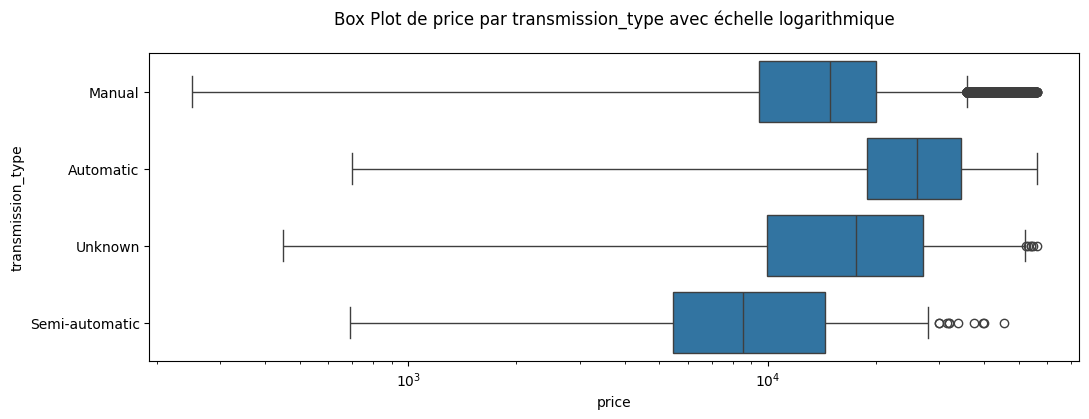

--- Résultats du test d'Anderson-Darling ---
Statistique d'Anderson-Darling: 1579.161208028032
Valeurs critiques: [0.576 0.656 0.787 0.918 1.092]
Niveaux de signification: [15.  10.   5.   2.5  1. ]
Les données ne suivent pas une distribution normale. Effectuer le test de Kruskal-Wallis.
--- Résultats du test de Kruskal-Wallis ---
Statistique de Kruskal-Wallis: 48207.293832522344
P-value: 0.0


In [63]:
analyze_data(df, 'price', 'transmission_type')

<div style="
    background-color: #439cc8; 
    color: white; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    <p>💡 Le type de transmission joue sur le prix (P-value: 0.0)</p>
</div>

In [64]:
df.transmission_type.value_counts()

transmission_type
Automatic         94117
Manual            90949
Unknown             724
Semi-automatic      182
Name: count, dtype: int64

In [65]:
df.query("transmission_type=='Unknown'").head()

,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,mileage_in_km,version,price,fuel_consumption_g_km_num,fuel_consumption_l_100km_num,month
362,alfa-romeo,Alfa Romeo MiTo,black,2010-08-01,2010,95.0,Unknown,Petrol,193000.0,Turismo Zahnriemen neu Scheckheft gepflegt,3750.0,138.0,5.9,8
415,alfa-romeo,Alfa Romeo Giulietta,white,2011-02-01,2011,120.0,Unknown,Petrol,60000.0,Turismo (191),9500.0,156.0,6.6,2
526,alfa-romeo,Alfa Romeo MiTo,black,2015-12-01,2015,105.0,Unknown,Petrol,35000.0,Junior (11.2014-->) (145),11799.0,100.0,4.2,12
584,alfa-romeo,Alfa Romeo Giulia,grey,2017-05-01,2017,209.0,Unknown,Diesel,83961.0,2.2d Veloce Q4 1.Hand*84TKM*ACC*Memory*,24950.0,122.0,4.7,5
702,alfa-romeo,Alfa Romeo Stelvio,black,2018-06-01,2018,200.0,Unknown,Petrol,36500.0,2.0Turbo 16V - Ratenzahlung mgl.,33900.0,161.0,7.0,6


In [66]:
df.query("version=='2.2d Veloce Q4 1.Hand*84TKM*ACC*Memory*'")

,brand,model,color,registration_date,year,power_ps,transmission_type,fuel_type,mileage_in_km,version,price,fuel_consumption_g_km_num,fuel_consumption_l_100km_num,month
584,alfa-romeo,Alfa Romeo Giulia,grey,2017-05-01,2017,209.0,Unknown,Diesel,83961.0,2.2d Veloce Q4 1.Hand*84TKM*ACC*Memory*,24950.0,122.0,4.7,5


<div style="
    background-color: #439cc8; 
    color: #fff; 
    font-size: 16px; 
    font-style: italic; 
    padding: 10px 15px; 
    margin-bottom: 15px; 
    border-radius: 8px;">
    💡 Suppression des transmissions dont le type est inconnu
</div>

In [67]:
df = df[df["transmission_type"]!="Unknown"].copy()

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.2.5 - Matrice de corrélation</h4>
</div>

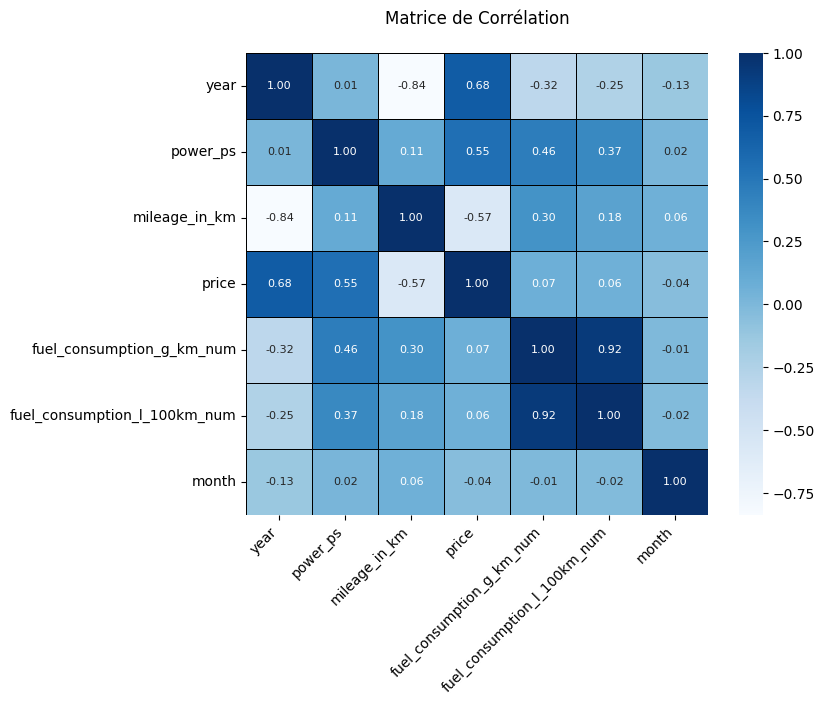

In [68]:
# Calcul de la matrice de corrélation en spécifiant numeric_only=True
correlation_matrix = df.corr(numeric_only=True, method="spearman")

plt.figure(figsize=(8, 6))
# Création d'une heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True,
    square=True,
    linewidths=0.5,
    linecolor="black",
    annot_kws={"size": 8},
)

# Ajustement des étiquettes et du titre
plt.title("Matrice de Corrélation\n", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# Affichage de la figure
plt.show()


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.2.6 - Pairplot pour repérer les liens entre les variables</h4>
</div>

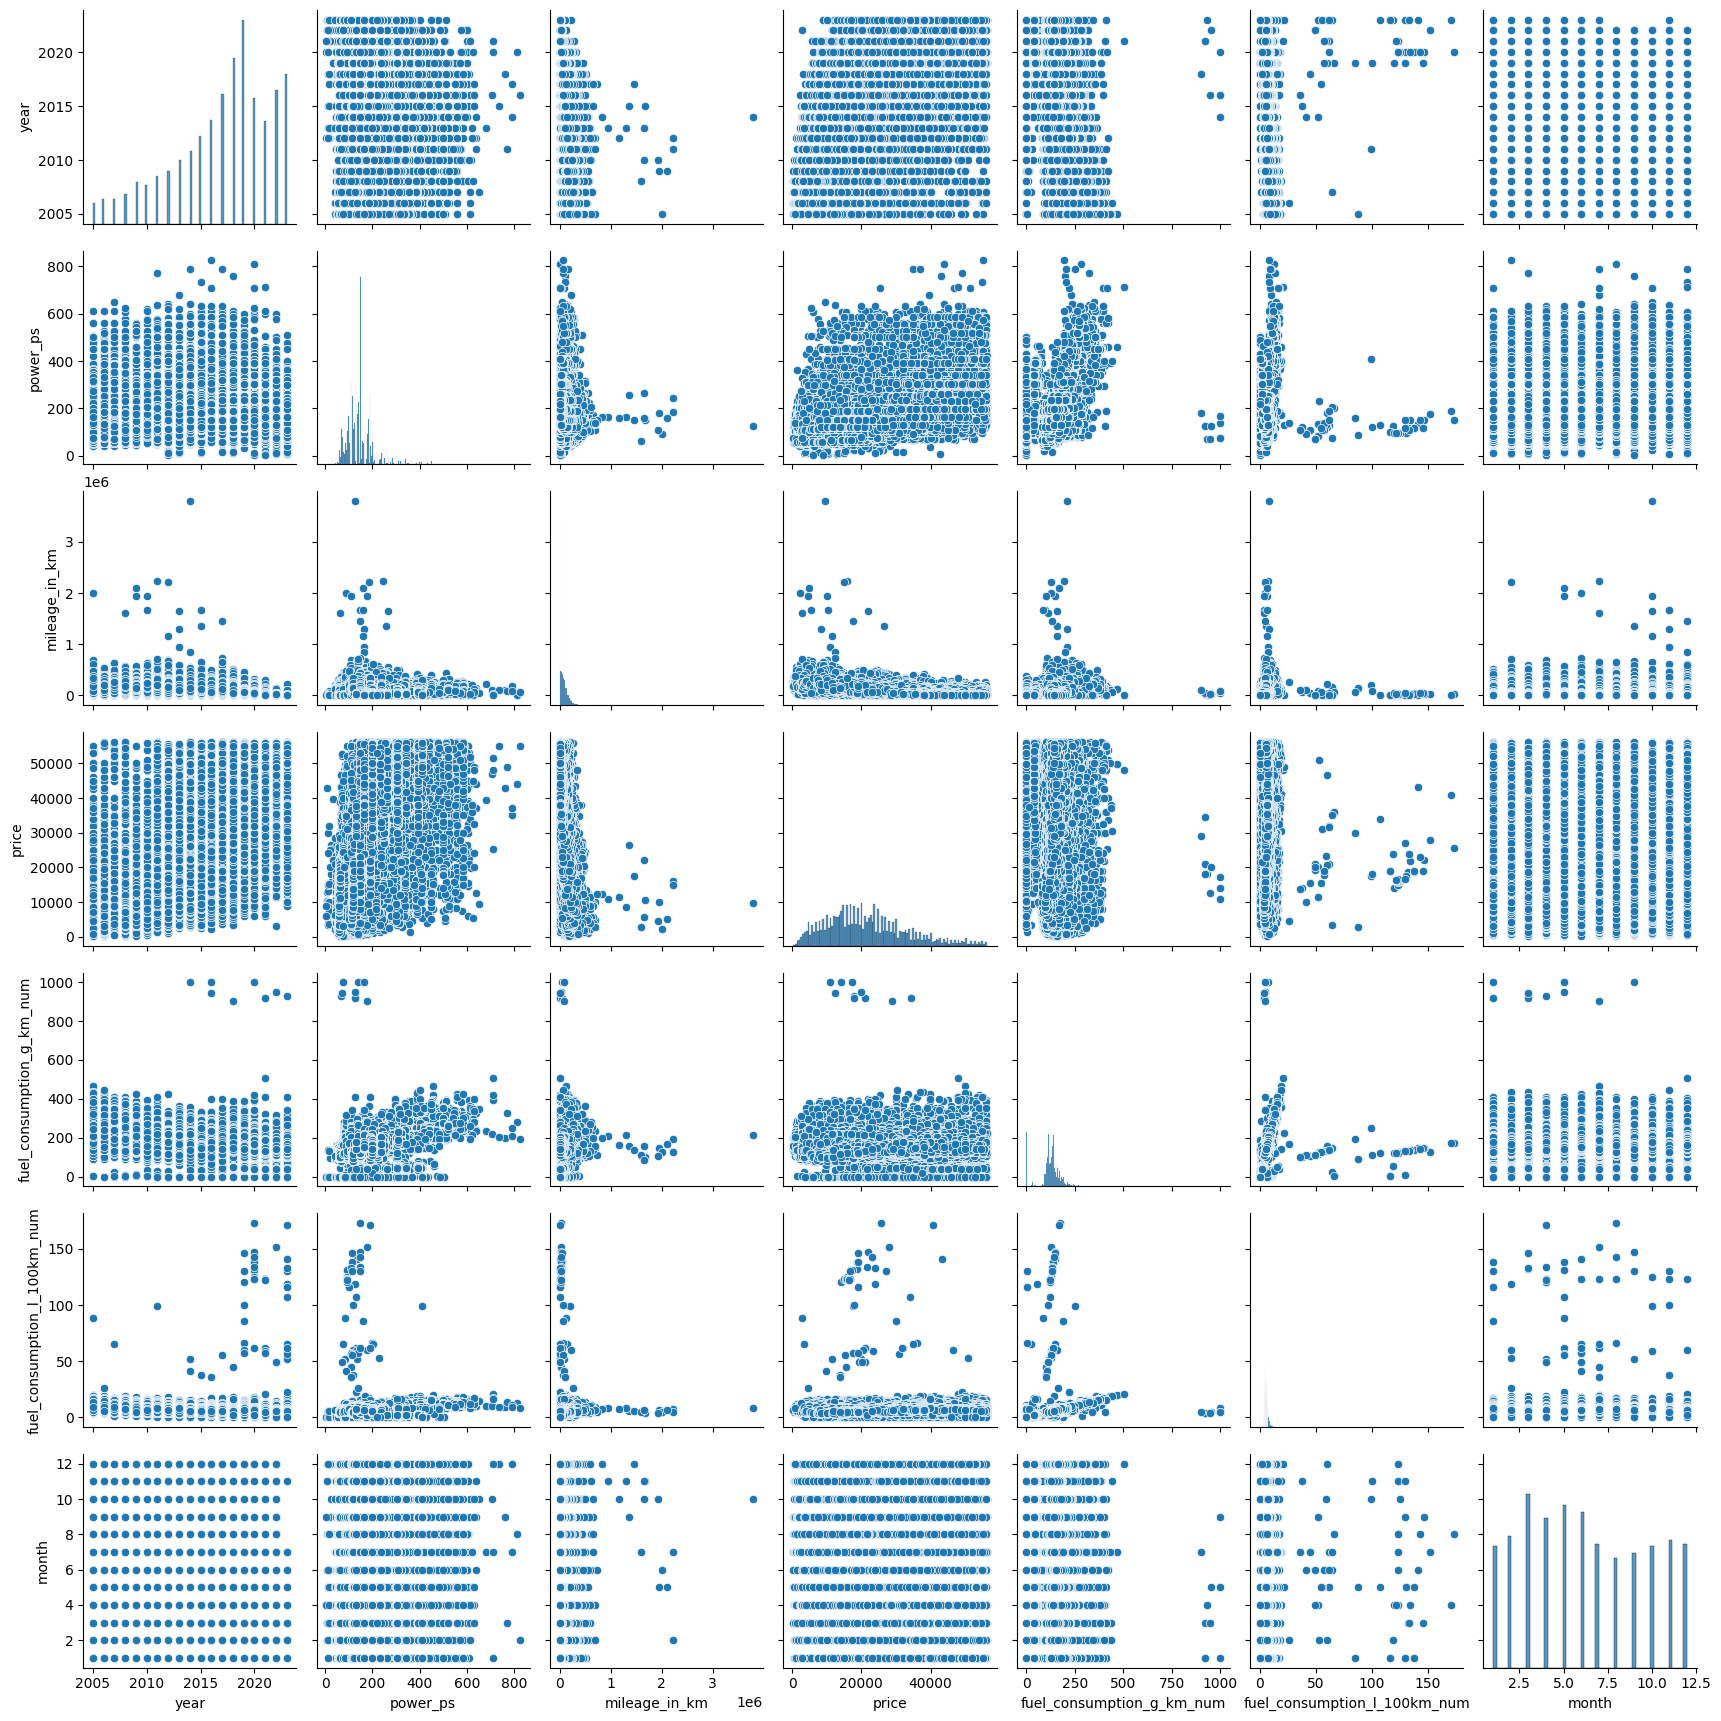

In [69]:
# Filtrer uniquement les colonnes numériques
df_numeric = df.select_dtypes(include=["number"]).copy()

# Générer le pairplot uniquement pour les colonnes numériques
sns.pairplot(df_numeric)

# Afficher le plot
plt.show()


<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">3.3 - Multivarié</h3>
</div>

<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.3.1 - Préparation des données</h4>
</div>

In [70]:
# Colonnes numériques
num_features = [
    "year",
    "price",
    "power_ps",
    "fuel_consumption_g_km_num",
    "mileage_in_km",
    "month",
]

# Colonnes catégorielles à binariser
cat_features = ["transmission_type", "fuel_type"]

# Copie du DataFrame en gardant les variables d'intérêt
df_price_std = df[num_features + cat_features].copy()

# Binarisation des variables catégorielles
df_price_std = pd.get_dummies(df_price_std, columns=cat_features, drop_first=True)

# Combinaison des colonnes numériques et binarisées
final_columns = num_features + [
    col for col in df_price_std.columns if col not in num_features
]

# Standardisation sur toutes les colonnes
scaler = StandardScaler()
df_price_std[final_columns] = scaler.fit_transform(df_price_std[final_columns])

# Afficher un aperçu des données
df_price_std.head()


,year,price,power_ps,fuel_consumption_g_km_num,mileage_in_km,month,transmission_type_Manual,transmission_type_Semi-automatic,fuel_type_Diesel Hybrid,fuel_type_Electric,fuel_type_Hybrid,fuel_type_LPG,fuel_type_Petrol
135,-2.661629,-0.932638,0.437569,3.412484,0.638811,1.101476,1.01825,-0.03136,-0.040476,-0.163949,-0.226067,-0.062028,0.866283
136,-2.661629,-1.337565,0.158384,1.911642,1.709856,-0.079166,1.01825,-0.03136,-0.040476,-0.163949,-0.226067,-0.062028,0.866283
137,-2.661629,-0.296596,1.260432,3.591689,0.883239,-0.079166,1.01825,-0.03136,-0.040476,-0.163949,-0.226067,-0.062028,0.866283
139,-2.661629,-1.673639,0.158384,1.620434,1.915875,0.806316,1.01825,-0.03136,-0.040476,-0.163949,-0.226067,-0.062028,0.866283
140,-2.661629,-1.157463,1.260432,3.591689,0.697309,1.101476,1.01825,-0.03136,-0.040476,-0.163949,-0.226067,-0.062028,0.866283


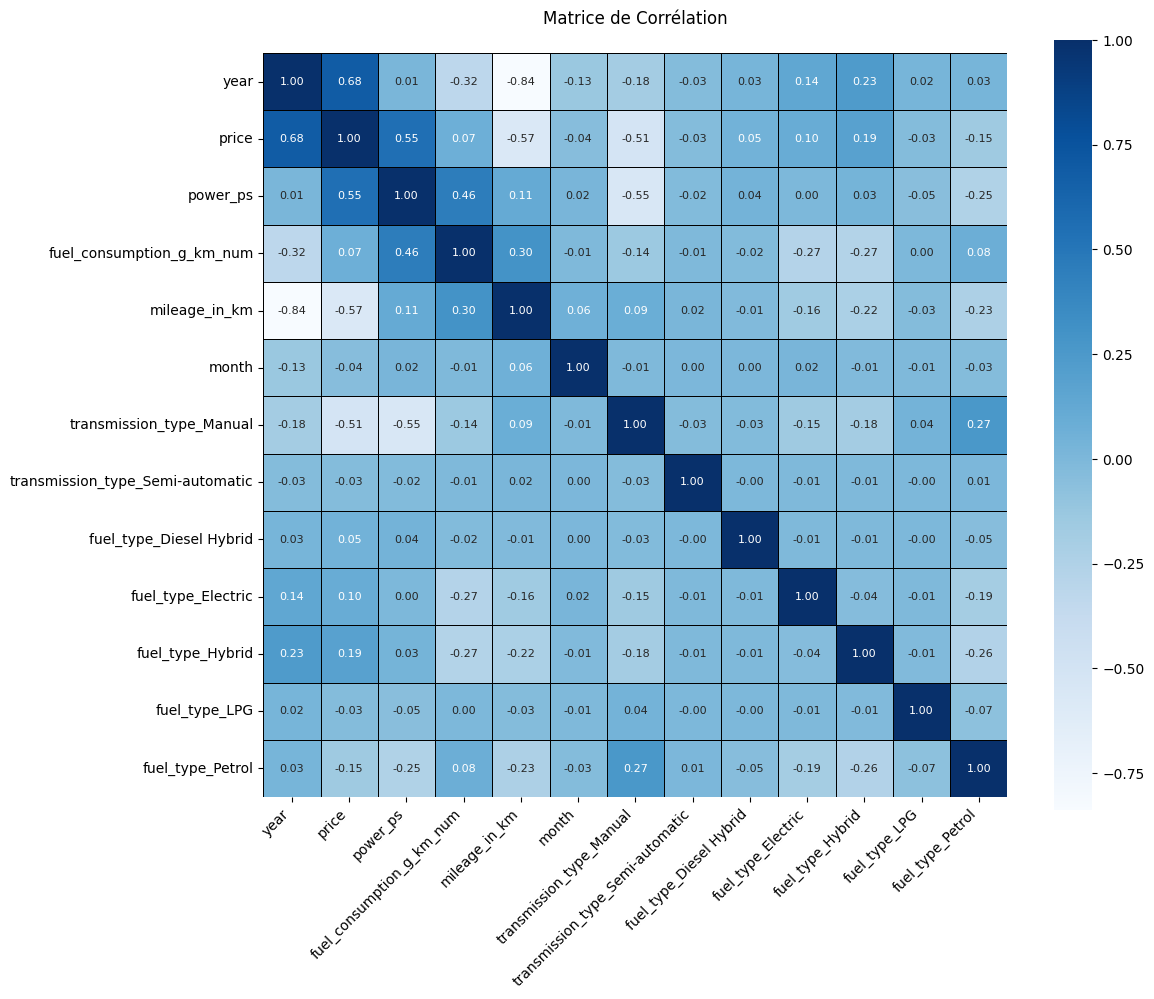

In [71]:
correlation_matrix = df_price_std.corr(numeric_only=True, method="spearman")

plt.figure(figsize=(12, 10))
# Création d'une heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    cbar=True,
    square=True,
    linewidths=0.5,
    linecolor="black",
    annot_kws={"size": 8},
)

# Ajustement des étiquettes et du titre
plt.title("Matrice de Corrélation\n", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

# Affichage de la figure
plt.show()


In [72]:
df_price_std.drop(
    [
        "month",
        "transmission_type_Semi-automatic",
        "fuel_type_Diesel Hybrid",
        "fuel_type_LPG",
    ],
    axis=1,
    inplace=True,
)


<div style="width: 50%; border-bottom: 2px solid #b3d9ef;" >
<h4 style="background-color:white;margin: auto; padding: 20px; color: #439cc8; ">3.3.2 - Analyse en composantes principales (ACP)</h4>
</div>

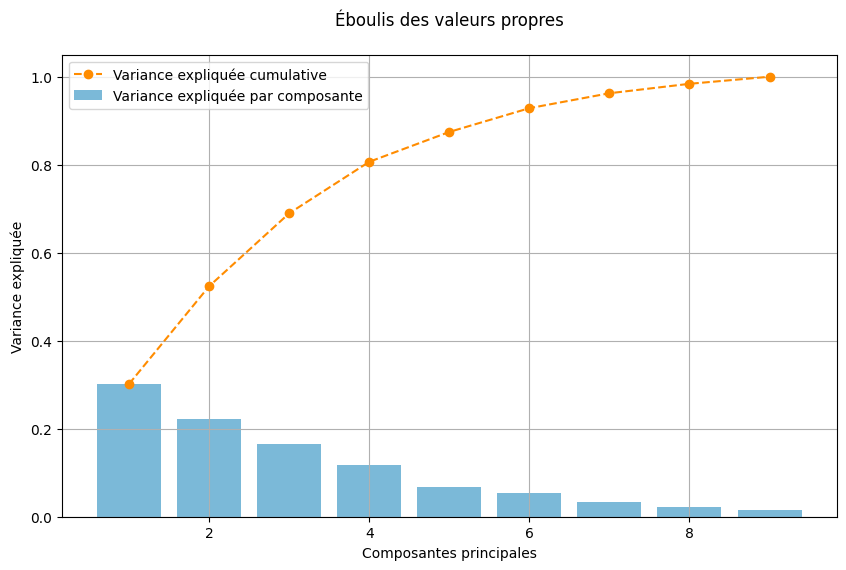

In [73]:
# Initialisation de l'ACP
pca = PCA()
pca.fit(df_price_std)


def scree_plot(pca, fig_size=(10, 6)):
    # Calcul de la variance expliquée et cumulée
    explained_variance = pca.explained_variance_ratio_
    cumulative_variance = np.cumsum(explained_variance)

    # Déclaration du graphique
    plt.figure(figsize=fig_size)

    # Barres pour la variance expliquée de chaque composante
    plt.bar(
        range(1, len(explained_variance) + 1),
        explained_variance,
        alpha=0.7,
        align="center",
        label="Variance expliquée par composante",
        color="#439cc8",
    )

    # Courbe de la variance expliquée cumulative
    plt.plot(
        range(1, len(cumulative_variance) + 1),
        cumulative_variance,
        marker="o",
        linestyle="--",
        color="darkorange",
        label="Variance expliquée cumulative",
    )

    plt.xlabel("Composantes principales")
    plt.ylabel("Variance expliquée")
    plt.title("Éboulis des valeurs propres\n")
    plt.legend(loc="best")
    plt.grid(True)
    plt.show()


# Lancement de la fonction
scree_plot(pca)


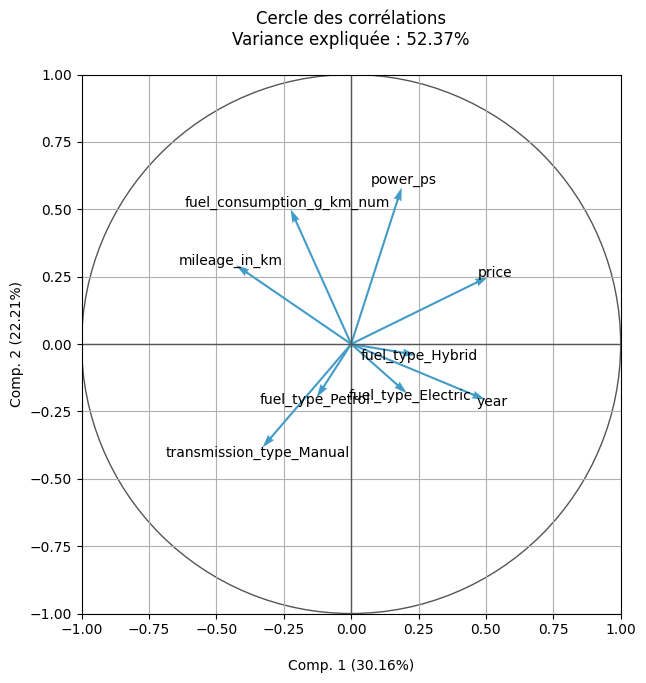

In [74]:
# Fonction pour juste dessiner le cercle
def draw_correlation_circle(ax):
    ax.add_artist(plt.Circle((0, 0), 1, color="#555", fill=False, linestyle="-"))


# Fonction pour dessiner le cercle des corrélations
def plot_correlation_circle(pca, components, feature_names):
    arrow_size = 0.05
    fig, ax = plt.subplots(figsize=(7, 7))
    draw_correlation_circle(ax)

    for i, feature in enumerate(feature_names):
        x, y = pca.components_[components, i]
        norm = np.linalg.norm([x, y])

        if norm != 0:
            x_base = x - x / norm * arrow_size
            y_base = y - y / norm * arrow_size
            ax.plot([0, x_base], [0, y_base], color="#439cc8")
            ax.quiver(
                x_base,
                y_base,
                x / norm * arrow_size,
                y / norm * arrow_size,
                angles="xy",
                scale_units="xy",
                scale=1,
                color="#439cc8",
            )

        ax.text(x * 1.05, y * 1.05, feature, color="black", ha="center", va="center")

    var_ratio = pca.explained_variance_ratio_[components] * 100

    x_label = f"\nComp. {components[0] + 1} ({var_ratio[0]:.2f}%)"
    y_label = f"Comp. {components[1] + 1} ({var_ratio[1]:.2f}%)"
    title = f"Cercle des corrélations\nVariance expliquée : {var_ratio.sum():.2f}%\n"

    ax.set_xlabel(x_label)
    ax.set_ylabel(y_label)
    ax.set_title(title)
    ax.grid()
    ax.axhline(0, color="#555", linewidth=1)
    ax.axvline(0, color="#555", linewidth=1)
    ax.set_xlim([-1, 1])
    ax.set_ylim([-1, 1])
    ax.set_aspect("equal", adjustable="box")
    plt.show()


# Exemple sur composante 1 et 2 correspondants à [0,1]
plot_correlation_circle(pca, [0, 1], df_price_std.columns)


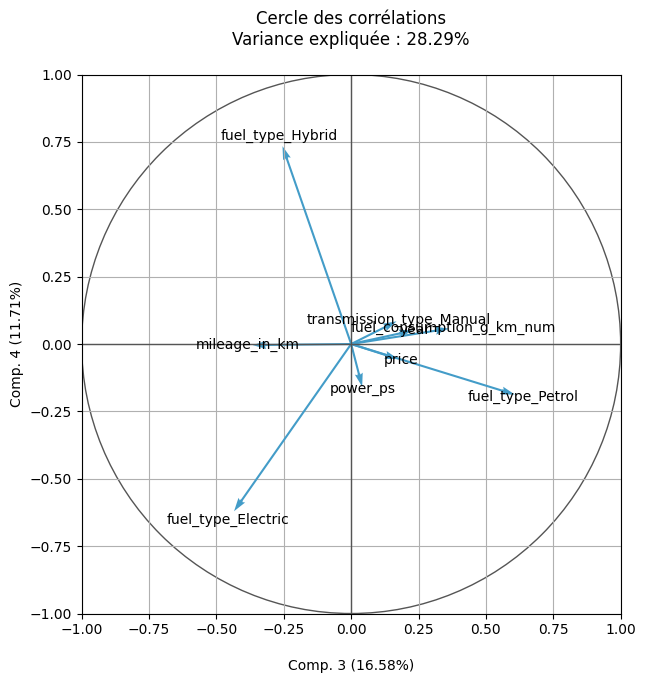

In [75]:
plot_correlation_circle(pca, [2,3], df_price_std.columns)

In [76]:
# Calcul des coefficients de charge
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

# Mise sous forme de DataFrame
loadings_df = pd.DataFrame(
    loadings,
    columns=[f"Composante {i + 1}" for i in range(pca.n_components_)],
    index=df_price_std.columns,
)

# Affichage avec mise en forme
display(loadings_df.style.background_gradient(cmap="Blues"))


,Composante 1,Composante 2,Composante 3,Composante 4,Composante 5,Composante 6,Composante 7,Composante 8,Composante 9
year,0.820152,-0.292013,0.277907,0.050937,-0.241708,-0.060904,-0.114209,0.230462,-0.184308
price,0.838610,0.353048,0.213610,-0.057465,-0.162783,0.109651,-0.024842,0.053211,0.284945
power_ps,0.308809,0.821469,0.049927,-0.162520,0.125662,0.329998,-0.204016,-0.118896,-0.143095
fuel_consumption_g_km_num,-0.370455,0.707286,0.442867,0.058820,-0.090251,0.047748,0.361586,0.135725,-0.057734
mileage_in_km,-0.703091,0.413168,-0.446018,-0.004047,-0.021658,-0.009718,-0.238705,0.274555,0.055569
transmission_type_Manual,-0.542139,-0.542886,0.205692,0.086436,-0.300595,0.519520,-0.030699,0.001297,0.019576
fuel_type_Electric,0.340892,-0.258869,-0.530736,-0.636881,0.165243,0.212664,0.209121,0.113489,-0.018583
fuel_type_Hybrid,0.396767,-0.057228,-0.311160,0.753588,0.343809,0.207641,0.086720,0.075803,0.002103
fuel_type_Petrol,-0.210365,-0.279960,0.742106,-0.192598,0.515411,0.029867,-0.101176,0.102981,0.046646


<div style="background-color: #439cc8;border-radius: 8px;font-size:2rem;width: 90%; " >
<h2 style="margin: auto; padding: 20px; color:#fff; ">4 - Export des données</h2>
</div>

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">4.1 - Conversion des types</h3>
</div>

In [77]:
# Conversion des types des colonnes dans le DataFrame df
df = df.astype(
    {
        "year": "int16",  # Années (1995-2023)
        "power_ps": "int16",  # Puissance en PS (5-825)
        "mileage_in_km": "int32",  # Kilométrage en km (0-3,800,000)
        "price": "int32",  # Prix (149-56,222)
        "fuel_consumption_g_km_num": "float32",  # Consommation en g/km (0-999)
        "fuel_consumption_l_100km_num": "float32",  # Consommation en l/100km (0-173)
        "month": "int8",  # Mois (1-12)
    }
)


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 185248 entries, 135 to 251078
Data columns (total 14 columns):
 #   Column                        Non-Null Count   Dtype         
---  ------                        --------------   -----         
 0   brand                         185248 non-null  object        
 1   model                         185248 non-null  object        
 2   color                         185248 non-null  object        
 3   registration_date             185248 non-null  datetime64[ns]
 4   year                          185248 non-null  int16         
 5   power_ps                      185248 non-null  int16         
 6   transmission_type             185248 non-null  object        
 7   fuel_type                     185248 non-null  object        
 8   mileage_in_km                 185248 non-null  int32         
 9   version                       185248 non-null  object        
 10  price                         185248 non-null  int32         
 11  fuel_consumption

<div style="border: 1px solid #439cc8;border-radius: 8px;width: 90%;" >
<h3 style="margin: auto; padding: 20px; color: #439cc8; ">4.2 - Export</h3>
</div>

In [79]:
# Enregistrer le DataFrame en format Parquet
fic = r"D:\ENI\CHAPITRE_09\used_cars_germany\data_clean.parquet"
df.to_parquet(fic, engine="pyarrow", index=False)
